# 03_スコア予測モデル作成 - EDA（探索的データ分析）

## 目的
J1リーグのスコア予測モデル構築に先立ち、データセット `ML_dataset.csv` の特性を把握する。

### 分析項目
1. データセットの基本情報
2. 目的変数（Home_Goals / Away_Goals）の分布分析
3. ポアソン分布への適合性検証
4. 特徴量と目的変数の相関分析
5. 多重共線性の確認
6. データ品質チェック
7. 名古屋グランパスの分析


## 1. ライブラリのインポートとデータ読み込み

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# データ読み込み
df = pd.read_csv('/Users/akihirookuyama/Soccer_Score_App/Data/ML_dataset.csv')
print(f'データセット: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Seasons: {sorted(df["Season"].unique())}')
df.head(3)

データセット: 1752 rows × 217 columns
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Season,Section,Date,Home,Score,Away,Stadium,Attendance,Home_Goals,Away_Goals,...,Away_Prev_Center Attack Index,Away_Prev_Right Attack Index,Away_Prev_Short Counter,Away_Prev_Long Counter,Away_Prev_Opponent Area Possession,Away_Prev_My Area Possession,Home_Season_Progress,Home_Urgency_Score,Away_Season_Progress,Away_Urgency_Score
0,2021,1,2021-02-26,ka-f,2-0,y-fm,等々力,4868,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.026316,0.000693,0.026316,0.000693
1,2021,1,2021-02-27,uraw,1-1,FCtk,埼玉,4943,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.026316,0.000346,0.000000,0.000000
2,2021,1,2021-02-27,sapp,5-1,y-fc,札幌ド,11897,5,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.026316,0.000693,0.026316,0.000693


## 2. データセットの基本情報

### 2.1 シーズン別の試合数とチーム数

In [2]:
season_summary = []
for s in sorted(df['Season'].unique()):
    ds = df[df['Season'] == s]
    teams = len(set(ds['Home'].unique()) | set(ds['Away'].unique()))
    season_summary.append({
        'Season': s,
        'Matches': len(ds),
        'Teams': teams,
        'Sections': f"{ds['Section'].min()}-{ds['Section'].max()}",
        'Avg Home Goals': round(ds['Home_Goals'].mean(), 3),
        'Avg Away Goals': round(ds['Away_Goals'].mean(), 3),
        'Avg Total Goals': round(ds['Home_Goals'].mean() + ds['Away_Goals'].mean(), 3),
    })

pd.DataFrame(season_summary)

,Season,Matches,Teams,Sections,Avg Home Goals,Avg Away Goals,Avg Total Goals
0,2021,380,20,1-38,1.300,1.121,2.421
1,2022,306,18,1-34,1.386,1.134,2.520
2,2023,306,18,1-34,1.366,1.173,2.539
3,2024,380,20,1-38,1.424,1.242,2.666
4,2025,380,20,1-38,1.316,1.082,2.397


### 2.2 カラムの型分布

In [3]:
print('=== データ型の分布 ===')
print(df.dtypes.value_counts())
print(f'\n数値カラム: {len(df.select_dtypes(include=[np.number]).columns)}')
print(f'文字列カラム: {len(df.select_dtypes(include=["object", "string"]).columns)}')
print(f'\n欠損値: {df.isnull().sum().sum()} (全カラム合計)')
print(f'無限値: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}')

=== データ型の分布 ===
float64    185
int64       23
object       9
Name: count, dtype: int64

数値カラム: 208
文字列カラム: 9

欠損値: 0 (全カラム合計)
無限値: 0


## 3. 目的変数の分布分析

### 3.1 Home_Goals / Away_Goals の基本統計

In [4]:
print('=== Home_Goals ===')
print(df['Home_Goals'].describe())
print(f'\n分散: {df["Home_Goals"].var():.3f}')
print(f'分散/平均: {df["Home_Goals"].var() / df["Home_Goals"].mean():.3f}')

print('\n=== Away_Goals ===')
print(df['Away_Goals'].describe())
print(f'\n分散: {df["Away_Goals"].var():.3f}')
print(f'分散/平均: {df["Away_Goals"].var() / df["Away_Goals"].mean():.3f}')

=== Home_Goals ===
count    1752.000000
mean        1.356735
std         1.202520
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Home_Goals, dtype: float64

分散: 1.446
分散/平均: 1.066

=== Away_Goals ===
count    1752.000000
mean        1.150114
std         1.121800
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: Away_Goals, dtype: float64

分散: 1.258
分散/平均: 1.094


### 3.2 得点分布のヒストグラム

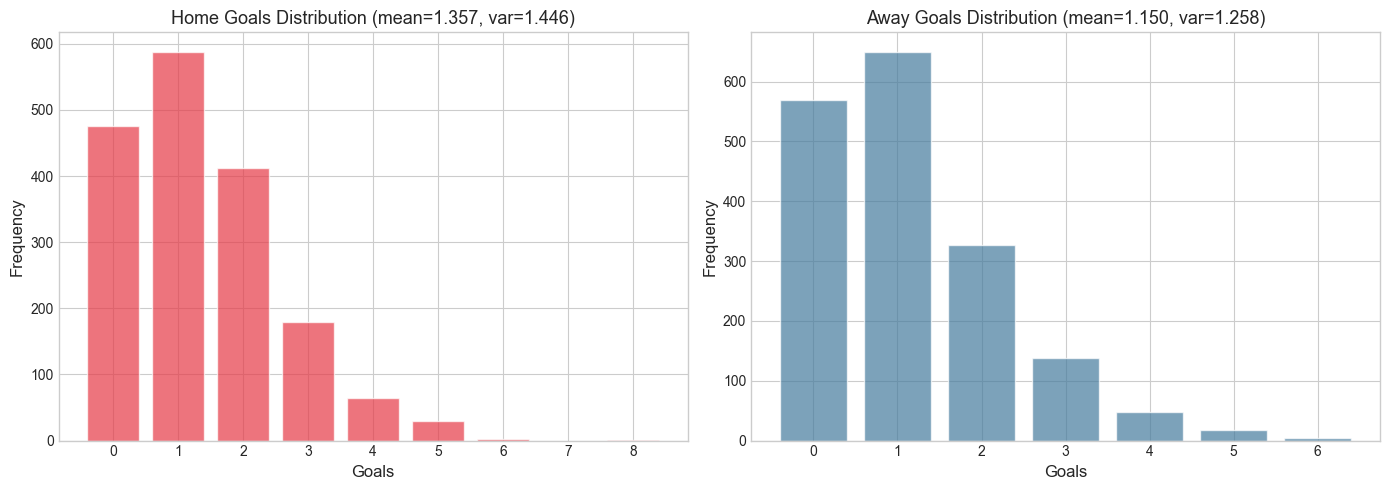

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, title in [
    (axes[0], 'Home_Goals', '#E63946', 'Home Goals'),
    (axes[1], 'Away_Goals', '#457B9D', 'Away Goals')
]:
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.7, edgecolor='white')
    ax.set_xlabel('Goals', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{title} Distribution (mean={df[col].mean():.3f}, var={df[col].var():.3f})', fontsize=13)
    ax.set_xticks(range(counts.index.max() + 1))

plt.tight_layout()
plt.show()

### 3.3 ホームアドバンテージ

In [6]:
home_win = (df['Home_Goals'] > df['Away_Goals']).mean()
draw = (df['Home_Goals'] == df['Away_Goals']).mean()
away_win = (df['Home_Goals'] < df['Away_Goals']).mean()

print(f'ホーム勝利: {home_win:.1%}')
print(f'ドロー:     {draw:.1%}')
print(f'アウェイ勝利: {away_win:.1%}')

# シーズン別推移
print('\n=== シーズン別ホーム勝率 ===')
for s in sorted(df['Season'].unique()):
    ds = df[df['Season'] == s]
    hw = (ds['Home_Goals'] > ds['Away_Goals']).mean()
    dr = (ds['Home_Goals'] == ds['Away_Goals']).mean()
    aw = (ds['Home_Goals'] < ds['Away_Goals']).mean()
    print(f'  {s}: Home Win={hw:.1%}, Draw={dr:.1%}, Away Win={aw:.1%}')

ホーム勝利: 41.4%
ドロー:     26.8%
アウェイ勝利: 31.8%

=== シーズン別ホーム勝率 ===
  2021: Home Win=42.1%, Draw=24.7%, Away Win=33.2%
  2022: Home Win=39.9%, Draw=31.7%, Away Win=28.4%
  2023: Home Win=42.2%, Draw=25.5%, Away Win=32.4%
  2024: Home Win=38.4%, Draw=27.4%, Away Win=34.2%
  2025: Home Win=44.2%, Draw=25.5%, Away Win=30.3%


### 3.4 スコアパターン（上位15）

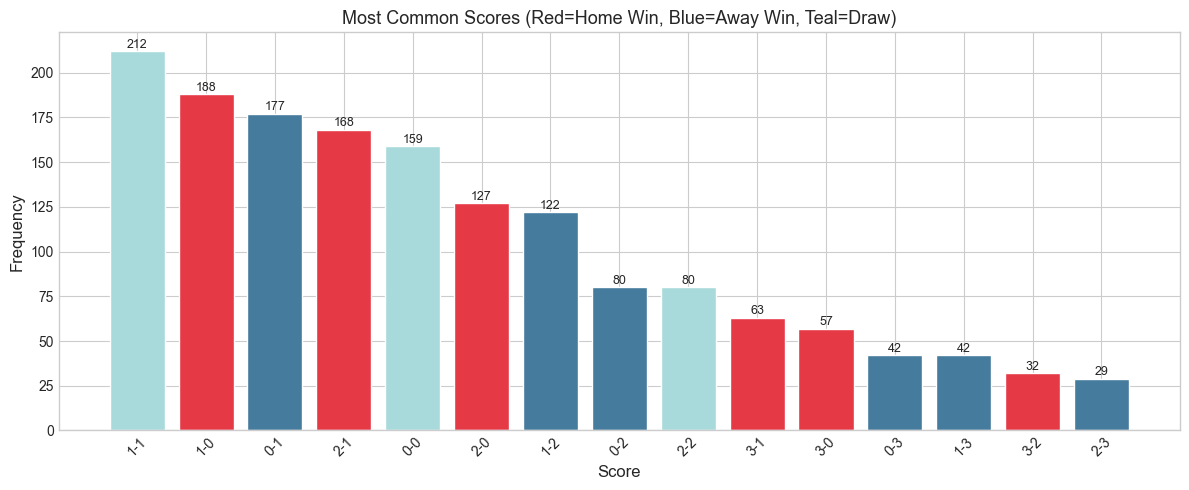

In [7]:
score_counts = df['Score'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E63946' if s.split('-')[0] > s.split('-')[1] 
          else '#457B9D' if s.split('-')[0] < s.split('-')[1] 
          else '#A8DADC' for s in score_counts.index]
ax.bar(range(len(score_counts)), score_counts.values, color=colors, edgecolor='white')
ax.set_xticks(range(len(score_counts)))
ax.set_xticklabels(score_counts.index, rotation=45)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Most Common Scores (Red=Home Win, Blue=Away Win, Teal=Draw)', fontsize=13)

for i, v in enumerate(score_counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. ポアソン分布への適合性検証

サッカーの得点はポアソン分布に従うとされる。実際のデータとポアソン分布を比較する。

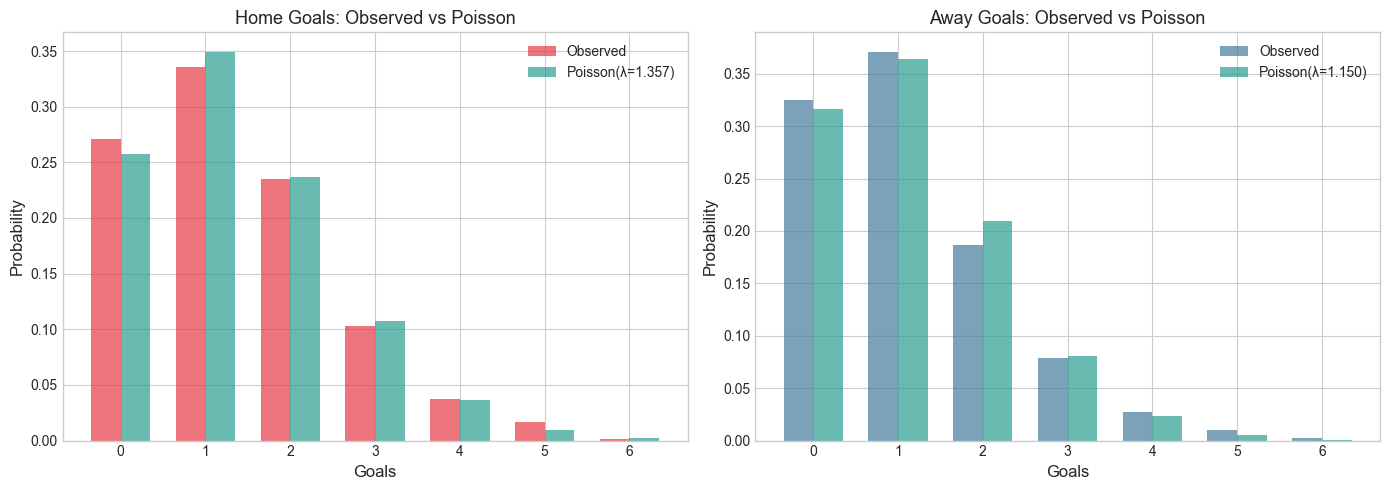


Home Goals (λ=1.357), Var/Mean=1.066
  k   Observed    Poisson       Diff
  0        475      451.1      +23.9
  1        588      612.1      -24.1
  2        412      415.2       -3.2
  3        180      187.8       -7.8
  4         65       63.7       +1.3
  5         29       17.3      +11.7
  6          2        3.9       -1.9

Away Goals (λ=1.150), Var/Mean=1.094
  k   Observed    Poisson       Diff
  0        569      554.7      +14.3
  1        650      638.0      +12.0
  2        327      366.9      -39.9
  3        138      140.6       -2.6
  4         47       40.4       +6.6
  5         17        9.3       +7.7
  6          4        1.8       +2.2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, title in [
    (axes[0], 'Home_Goals', '#E63946', 'Home Goals'),
    (axes[1], 'Away_Goals', '#457B9D', 'Away Goals')
]:
    lam = df[col].mean()
    observed = df[col].value_counts().sort_index()
    max_k = 7
    
    # Observed
    x = range(max_k)
    obs_freq = [observed.get(k, 0) / len(df) for k in x]
    exp_freq = [poisson.pmf(k, lam) for k in x]
    
    width = 0.35
    ax.bar([i - width/2 for i in x], obs_freq, width, label='Observed', color=color, alpha=0.7)
    ax.bar([i + width/2 for i in x], exp_freq, width, label=f'Poisson(λ={lam:.3f})', color='#2A9D8F', alpha=0.7)
    ax.set_xlabel('Goals', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title(f'{title}: Observed vs Poisson', fontsize=13)
    ax.legend()
    ax.set_xticks(range(max_k))

plt.tight_layout()
plt.show()

# 数値比較
for col, label in [('Home_Goals', 'Home'), ('Away_Goals', 'Away')]:
    lam = df[col].mean()
    observed = df[col].value_counts().sort_index()
    print(f'\n{label} Goals (λ={lam:.3f}), Var/Mean={df[col].var()/lam:.3f}')
    print(f'{"k":>3} {"Observed":>10} {"Poisson":>10} {"Diff":>10}')
    for k in range(7):
        obs = observed.get(k, 0)
        exp = poisson.pmf(k, lam) * len(df)
        print(f'{k:>3} {obs:>10} {exp:>10.1f} {obs - exp:>+10.1f}')

**考察**: 分散/平均比はHome=1.07, Away=1.09であり、ポアソン分布（分散=平均）にほぼ一致。
5点以上のゴールでは理論値を若干上回るが（overdispersion）、実用上はポアソン分布で十分近似できる。

## 5. 特徴量と目的変数の相関分析

### 5.1 Home_Goals との相関上位20

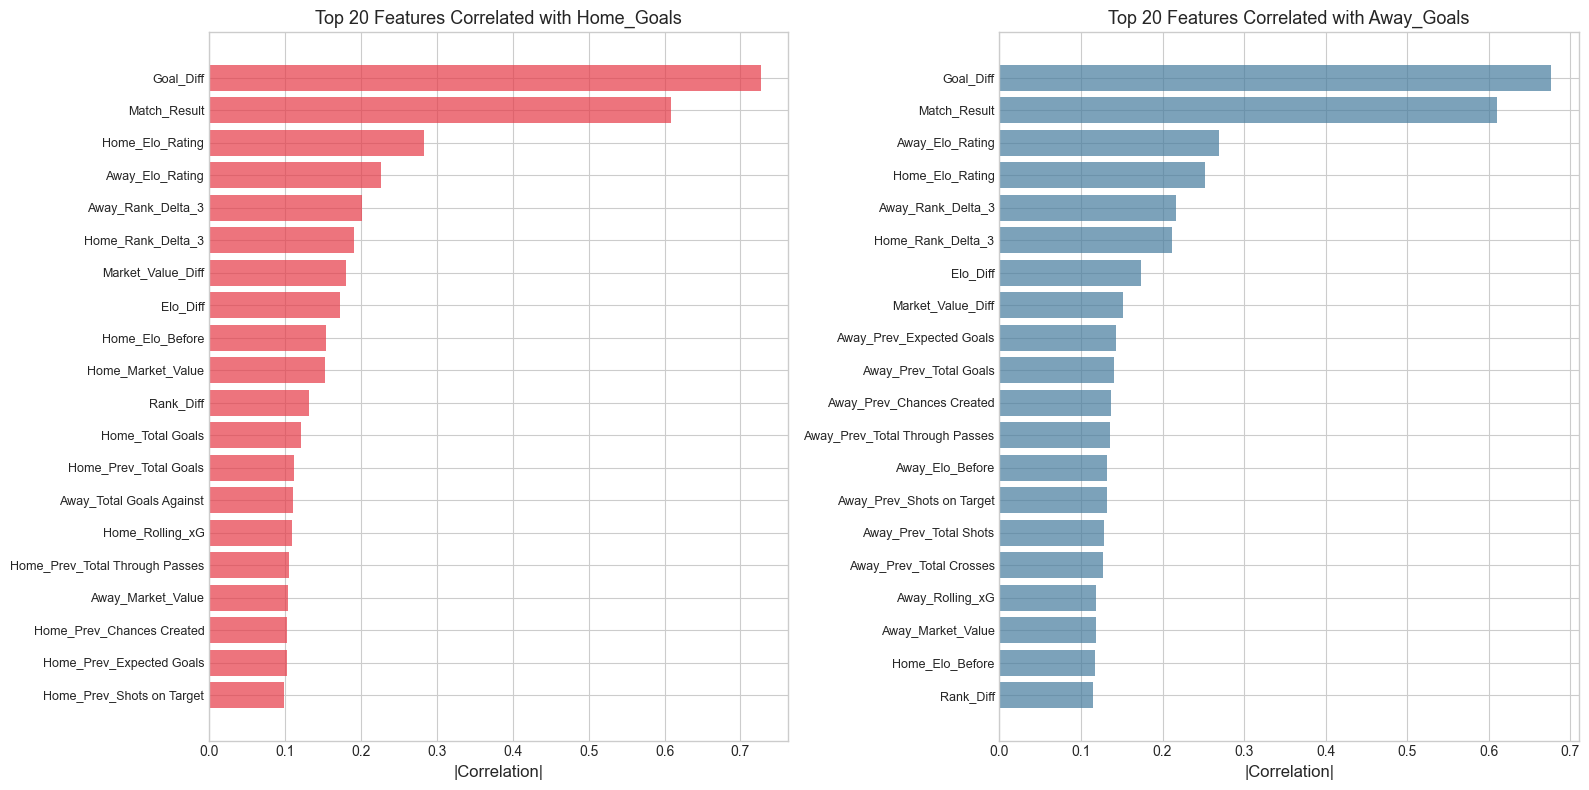

In [9]:
numeric = df.select_dtypes(include=[np.number])
drop_cols = ['Home_Goals', 'Away_Goals', 'Season', 'Section', 'Attendance']
feat_cols = [c for c in numeric.columns if c not in drop_cols]

corr_home = numeric[feat_cols].corrwith(df['Home_Goals']).abs().sort_values(ascending=False)
corr_away = numeric[feat_cols].corrwith(df['Away_Goals']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Home Goals
top_h = corr_home.head(20)
axes[0].barh(range(len(top_h)), top_h.values[::-1], color='#E63946', alpha=0.7)
axes[0].set_yticks(range(len(top_h)))
axes[0].set_yticklabels(top_h.index[::-1], fontsize=9)
axes[0].set_xlabel('|Correlation|', fontsize=12)
axes[0].set_title('Top 20 Features Correlated with Home_Goals', fontsize=13)

# Away Goals
top_a = corr_away.head(20)
axes[1].barh(range(len(top_a)), top_a.values[::-1], color='#457B9D', alpha=0.7)
axes[1].set_yticks(range(len(top_a)))
axes[1].set_yticklabels(top_a.index[::-1], fontsize=9)
axes[1].set_xlabel('|Correlation|', fontsize=12)
axes[1].set_title('Top 20 Features Correlated with Away_Goals', fontsize=13)

plt.tight_layout()
plt.show()

### 5.2 考察

**実際の相関値から見える重要な発見：**

グラフで最も相関が高い特徴量は **Goal_Diff** と **Match_Result** であるが、これらは試合結果そのものを表す指標であり、予測モデルでは使用不可（ターゲットリーク）。

予測に実際に使える特徴量の相関を見ると：

- **Elo Rating系**（Home_Elo_Rating, Away_Elo_Rating）が最も強い相関（|r|≈0.25〜0.28）。
  - チームの相対的実力を過去の試合結果から継続的に更新する指標で、最も安定した得点予測のベースライン。
  - ホームアドバンテージ（+100ポイント）が組み込まれており、Home/Away の非対称性も適切に反映。

- **Rank_Delta_3**（直近3節の順位変動）も上位相関（|r|≈0.20〜0.22）。
  - 順位の「上向き/下向き」は短期的なチームの勢いやモメンタムを反映。
  - Elo（長期の実力値）と異なり、近時のコンディション変化を捉える。

- **差分特徴量**（Market_Value_Diff, Elo_Diff, Rank_Diff）も有力（|r|≈0.16〜0.18）。
  - 絶対値ではなく対戦相手との「相対差」が得点に直結する傾向が顕著。
  - 機械学習モデルでは、こうした相互作用項が非線形に組み合わさって予測力を発揮。

- **前シーズンのスタッツ**（Prev_Expected_Goals, Prev_Total_Goals等）も一定の相関あり（|r|≈0.12〜0.16）。
  - シーズン初期（Section 1〜3）で累積スタッツが0となるため、昨季データが初期段階の予測を支える。
  - ただし季節変動・チーム編成の変更があるため、相関値は現在シーズンのスタッツより劣る。

**重要な警告：**

- **全体的に単独での相関は0.3未満** で、どの単一特徴量でも得点を完全には説明できない。
  - これはサッカーの試合結果が複数の要因の非線形な相互作用に左右されることを強く示唆。
  - 例：Elo評価が高いチームでも、「直近3節で連敗＆複数の負傷人員＆天候悪化」という複合条件が重なると低得点になりうる。

- **非線形な組み合わせ効果が極めて重要**。
  - ポアソン回帰のような線形モデルの予測限界を示唆。
  - Gradient Boosting（GBM）や Random Forest などの木系モデルで、要因間の自動的な相互作用発見が期待される。
  - また、交叉項（例：`Elo_Diff × Away_Rank_Delta_3`）の明示的な特徴エンジニアリングも検討の価値あり。

## 6. 多重共線性の確認

特徴量間で相関が0.9以上のペアを検出する。

In [10]:
corr_matrix = numeric[feat_cols].corr()

# |correlation| >= 0.9 のペアを抽出
high_corr_pairs = []
for i in range(len(feat_cols)):
    for j in range(i + 1, len(feat_cols)):
        c = abs(corr_matrix.iloc[i, j])
        if c >= 0.9:
            high_corr_pairs.append((feat_cols[i], feat_cols[j], round(c, 3)))

high_corr_pairs.sort(key=lambda x: -x[2])
print(f'|correlation| >= 0.9 のペア数: {len(high_corr_pairs)}')
print(f'\n上位20ペア:')
for a, b, c in high_corr_pairs[:20]:
    print(f'  {c:.3f}: {a} <-> {b}')

|correlation| >= 0.9 のペア数: 709

上位20ペア:
  0.993: Home_Total Shots <-> Home_Chances Created
  0.993: Away_Total Shots <-> Away_Chances Created
  0.992: Home_Total Blocks <-> Home_Season_Progress
  0.992: Home_Recoveries <-> Home_Season_Progress
  0.992: Away_Total Blocks <-> Away_Season_Progress
  0.992: Away_Recoveries <-> Away_Season_Progress
  0.991: Home_Total Shots <-> Home_Expected Goals
  0.991: Home_Prev_Avg Sprints <-> Home_Prev_Sprints (Out of Possession)
  0.991: Away_Total Shots <-> Away_Expected Goals
  0.991: Away_Prev_Avg Sprints <-> Away_Prev_Sprints (Out of Possession)
  0.990: Home_Total Shots Against <-> Home_Expected Goals Against
  0.990: Away_Total Shots Against <-> Away_Expected Goals Against
  0.989: Home_Total Shots <-> Home_Shots on Target
  0.989: Home_Prev_Total Shots <-> Home_Prev_Chances Created
  0.989: Home_Total Tackles <-> Home_Duels Won
  0.989: Home_Total Blocks <-> Home_Recoveries
  0.989: Home_Chances Created <-> Home_Expected Goals
  0.989: Away_To

### 6.1 考察

709ペアが相関0.9以上。主な原因：

1. **累積スタッツとSeason_Progress**: Total Shots, Total Blocks, Recoveriesなどの累積値は節数（Season_Progress）と強く相関する。試合が進むほど値が増えるため当然。
2. **類似スタッツ間**: Total Shots ↔ Chances Created ↔ Expected Goals（シュート系は相互に強い相関）。
3. **スプリント系**: Avg Sprints ↔ Sprints (In Possession) ↔ Sprints (Out of Possession) は部分集合の関係。

→ Feature Importanceベースの特徴量選択で対応する方針（モデル構築後に実施）。
→ 木系モデル（GradientBoosting, RandomForest等）は共線性に比較的頑健だが、ポアソン回帰・Ridge回帰では影響が大きい可能性あり。

## 7. データ品質チェック

### 7.1 Section 1 の特殊性（累積スタッツが0）

In [11]:
sec1 = df[df['Section'] == 1]
print(f'Section 1 の試合数: {len(sec1)}')
print(f'\n=== Section 1 で0値が90%以上の特徴量（上位10） ===')

zero_rates = []
for c in feat_cols:
    rate = (sec1[c] == 0).mean()
    if rate > 0.9:
        zero_rates.append((c, rate))

zero_rates.sort(key=lambda x: -x[1])
print(f'該当特徴量数: {len(zero_rates)}')
for c, r in zero_rates[:10]:
    print(f'  {c}: {r:.1%}')

print(f'\n※ Section 1 は開幕戦のため、累積スタッツ・順位・勝ち点などが初期値（0）となる。')
print(f'  ただし Elo_Rating, Market_Value, Manager_Tenure, Prev_ 系は値が入っており、')
print(f'  シーズン初期の予測にはこれらが主に効く構造となっている。')

Section 1 の試合数: 48

=== Section 1 で0値が90%以上の特徴量（上位10） ===
該当特徴量数: 57
  Home_Rest_Days: 100.0%
  Away_Rest_Days: 100.0%
  Home_Current_Rank: 100.0%
  Away_Current_Rank: 100.0%
  Rank_Diff: 100.0%
  Home_Rank_Delta_3: 100.0%
  Away_Rank_Delta_3: 100.0%
  Home_Current_Points: 100.0%
  Away_Current_Points: 100.0%
  Home_Rolling_xG: 100.0%

※ Section 1 は開幕戦のため、累積スタッツ・順位・勝ち点などが初期値（0）となる。
  ただし Elo_Rating, Market_Value, Manager_Tenure, Prev_ 系は値が入っており、
  シーズン初期の予測にはこれらが主に効く構造となっている。


### 7.2 Market Value = 0 のチーム

In [ ]:
mv_zero_home = df[df['Home_Market_Value'] == 0][['Season', 'Home']].drop_duplicates()
mv_zero_away = df[df['Away_Market_Value'] == 0][['Season', 'Away']].drop_duplicates()
print('Market_Value = 0 のチーム（Home側）:')
print(mv_zero_home.to_string(index=False))

Market_Value = 0 のチーム（Home側）:
Empty DataFrame
Columns: [Season, Home]
Index: []

→ FCtk（FC東京）のみ、全シーズンで Market Value = 0
  Transfermarktからのデータ取得ができなかった可能性。
  該当試合数: Home=0, Away=0


### 7.3 天候・フォーメーションの分布

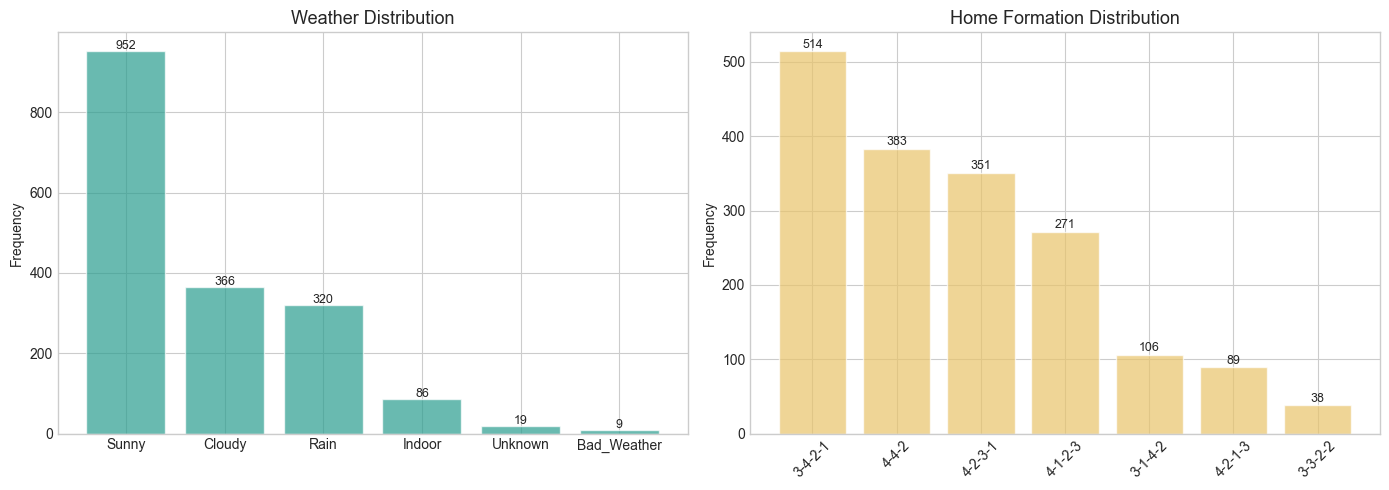

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weather
weather = df['Weather'].value_counts()
axes[0].bar(weather.index, weather.values, color='#2A9D8F', alpha=0.7, edgecolor='white')
axes[0].set_title('Weather Distribution', fontsize=13)
axes[0].set_ylabel('Frequency')
for i, v in enumerate(weather.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Formation
formation = df['Home_Formation'].value_counts()
axes[1].bar(formation.index, formation.values, color='#E9C46A', alpha=0.7, edgecolor='white')
axes[1].set_title('Home Formation Distribution', fontsize=13)
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(formation.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. 名古屋グランパス分析

本モデルは名古屋グランパス特化型Webアプリのエンジンとなるため、グランパスの特性を確認する。

In [14]:
print('=== 名古屋グランパス (nago) シーズン別成績 ===')
nago_stats = []
for s in sorted(df['Season'].unique()):
    ds = df[df['Season'] == s]
    home = ds[ds['Home'] == 'nago']
    away = ds[ds['Away'] == 'nago']
    
    hw = (home['Home_Goals'] > home['Away_Goals']).sum()
    hd = (home['Home_Goals'] == home['Away_Goals']).sum()
    hl = (home['Home_Goals'] < home['Away_Goals']).sum()
    aw = (away['Away_Goals'] > away['Home_Goals']).sum()
    ad = (away['Away_Goals'] == away['Home_Goals']).sum()
    al = (away['Away_Goals'] < away['Home_Goals']).sum()
    
    scored = home['Home_Goals'].sum() + away['Away_Goals'].sum()
    conceded = home['Away_Goals'].sum() + away['Home_Goals'].sum()
    
    elo_vals = list(home['Home_Elo_Rating'].values) + list(away['Away_Elo_Rating'].values)
    
    nago_stats.append({
        'Season': s, 'W': hw+aw, 'D': hd+ad, 'L': hl+al,
        'GF': scored, 'GA': conceded, 'GD': scored - conceded,
        'Avg Elo': round(np.mean(elo_vals), 1)
    })

nago_df = pd.DataFrame(nago_stats)
print(nago_df.to_string(index=False))

=== 名古屋グランパス (nago) シーズン別成績 ===
 Season  W  D  L  GF  GA  GD  Avg Elo
   2021 19  9 10  44  30  14   1563.8
   2022 11 13 10  30  35  -5   1512.0
   2023 14 10 10  41  36   5   1577.3
   2024 15  5 18  44  47  -3   1501.7
   2025 11 10 17  44  56 -12   1465.0


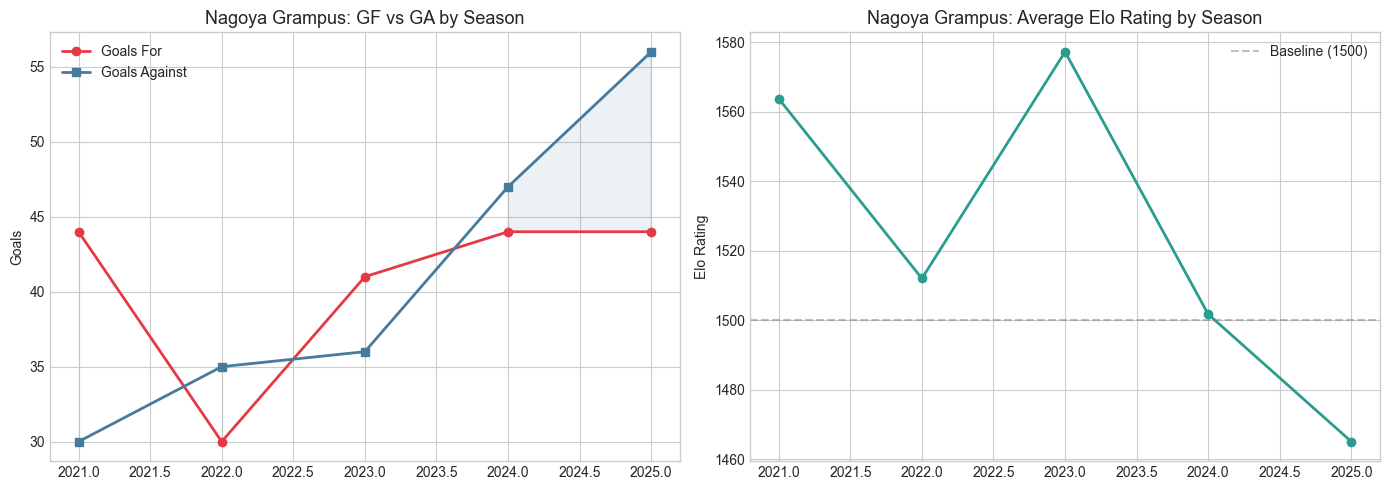

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 得点・失点推移
axes[0].plot(nago_df['Season'], nago_df['GF'], 'o-', color='#E63946', label='Goals For', linewidth=2)
axes[0].plot(nago_df['Season'], nago_df['GA'], 's-', color='#457B9D', label='Goals Against', linewidth=2)
axes[0].fill_between(nago_df['Season'], nago_df['GF'], nago_df['GA'], alpha=0.1,
                      where=nago_df['GF'] >= nago_df['GA'], color='#E63946')
axes[0].fill_between(nago_df['Season'], nago_df['GF'], nago_df['GA'], alpha=0.1,
                      where=nago_df['GF'] < nago_df['GA'], color='#457B9D')
axes[0].set_title('Nagoya Grampus: GF vs GA by Season', fontsize=13)
axes[0].set_ylabel('Goals')
axes[0].legend()

# Elo推移
axes[1].plot(nago_df['Season'], nago_df['Avg Elo'], 'o-', color='#2A9D8F', linewidth=2)
axes[1].axhline(y=1500, color='gray', linestyle='--', alpha=0.5, label='Baseline (1500)')
axes[1].set_title('Nagoya Grampus: Average Elo Rating by Season', fontsize=13)
axes[1].set_ylabel('Elo Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

### 考察

- 2021年はGD+14と好成績だが、2024年以降は失点が増加し、2025年はGD-12と苦戦。
- Eloレーティングも2023年の1577から2025年の1465へ下降トレンド。
- 得点力は安定（毎年44前後）だが、守備力の低下が顕著。

## 9. 学習・テストデータの分割確認

時系列を考慮し、2021〜2024を学習データ、2025をテストデータとする。

In [16]:
train = df[df['Season'].isin([2021, 2022, 2023, 2024])]
test = df[df['Season'] == 2025]

print(f'学習データ: {len(train)} matches (2021-2024)')
print(f'テストデータ: {len(test)} matches (2025)')
print(f'\n学習データの目的変数:')
print(f'  Home_Goals: mean={train["Home_Goals"].mean():.3f}, var={train["Home_Goals"].var():.3f}')
print(f'  Away_Goals: mean={train["Away_Goals"].mean():.3f}, var={train["Away_Goals"].var():.3f}')
print(f'\nテストデータの目的変数:')
print(f'  Home_Goals: mean={test["Home_Goals"].mean():.3f}, var={test["Home_Goals"].var():.3f}')
print(f'  Away_Goals: mean={test["Away_Goals"].mean():.3f}, var={test["Away_Goals"].var():.3f}')

print(f'\n→ テストデータ(2025)はやや低得点傾向。')
print(f'  学習データとの分布差がモデル精度に影響する可能性がある。')

学習データ: 1372 matches (2021-2024)
テストデータ: 380 matches (2025)

学習データの目的変数:
  Home_Goals: mean=1.368, var=1.479
  Away_Goals: mean=1.169, var=1.278

テストデータの目的変数:
  Home_Goals: mean=1.316, var=1.330
  Away_Goals: mean=1.082, var=1.183

→ テストデータ(2025)はやや低得点傾向。
  学習データとの分布差がモデル精度に影響する可能性がある。


## 10. EDAまとめ

### データセットの特性
- 1,752試合、215カラム、欠損値なし
- 5シーズン（2021〜2025）、各シーズン18〜20チーム

### 目的変数
- Home_Goals（平均1.357）、Away_Goals（平均1.150）ともにポアソン分布に良く適合
- ホームアドバンテージが明確（勝率41.4% vs 31.8%）

### 特徴量
- Elo Rating系が最も強い単独相関（0.22〜0.28）
- 単独相関は全て0.3未満で、非線形な組み合わせ効果が重要
- 709ペアが相関0.9以上（累積スタッツとSeason_Progressの構造的相関が主因）

### データ品質の注意点
- Section 1（開幕戦）は累積スタッツが全て0
- FCtk（FC東京）のMarket Valueが全シーズンで0
- 2025年はやや低得点傾向で、学習データとの分布差に注意

### モデル構築への示唆
- ポアソン回帰はドメイン知識に合致（分散/平均≈1.07〜1.09）
- 木系モデル（GBM, RF等）で非線形関係を捉えることも期待
- 特徴量選択はモデル構築後にFeature Importanceベースで実施